🎉 Figure 2 successfully generated and saved as: figure2_transition_comparison_final.png


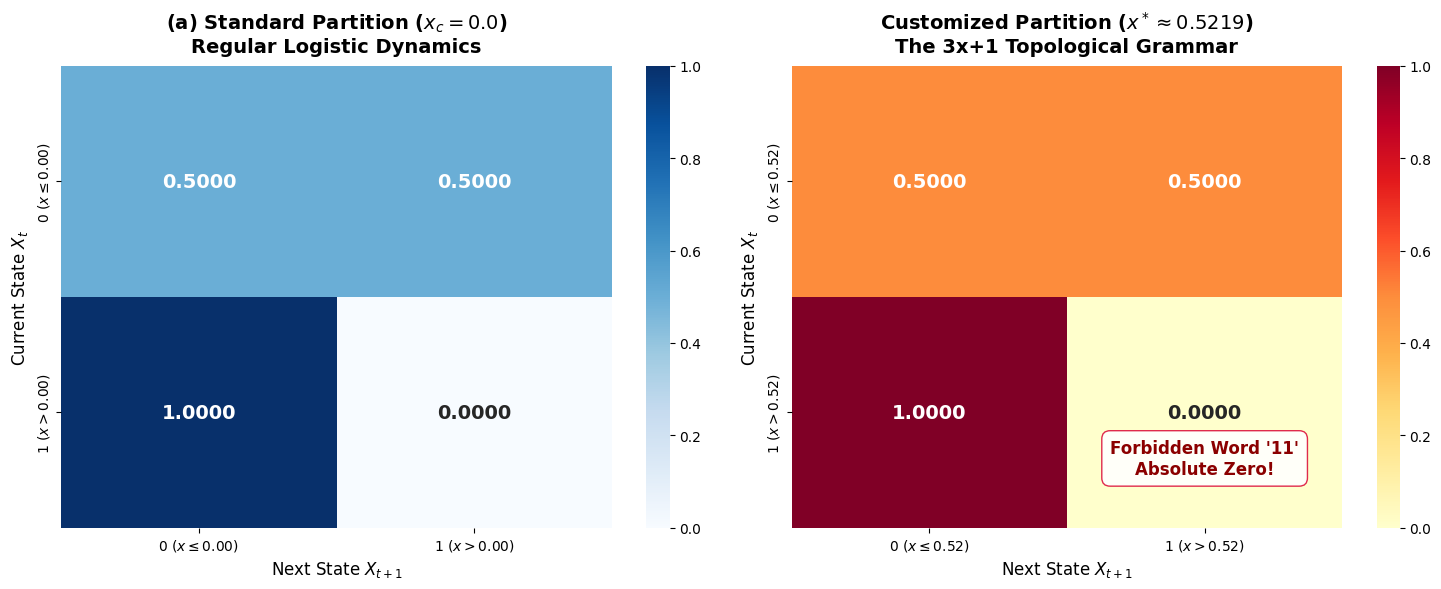

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Initialize System Parameters
# ==========================================
# Solving for mu in the super-stable period-3 window
roots = np.roots([1, -2, 1, -1])
mu = np.real(roots[np.isreal(roots)])[0]
# Solving for the unstable fixed point x*
x_star = (np.sqrt(1 + 4*mu) - 1) / (2*mu)

# ==========================================
# 2. Generate Trajectory (1 Million Steps)
# ==========================================
N_traj = 1000000
x_traj = np.zeros(N_traj)
x_traj[0] = 0.12345 
for i in range(1, N_traj):
    x_traj[i] = 1.0 - mu * x_traj[i-1]**2

# Burn-in: Remove transients to ensure we are on the attractor
x_traj = x_traj[1000:]

# ==========================================
# 3. Transition Matrix Calculation Function
# ==========================================
def get_transition_matrix(threshold):
    states = (x_traj > threshold).astype(int)
    # histogram2d to count transitions from current state to next state
    transitions, _, _ = np.histogram2d(states[:-1], states[1:], bins=2, range=[[-0.5, 1.5], [-0.5, 1.5]])
    # Normalize by row sums to get transition probabilities
    M = transitions / transitions.sum(axis=1, keepdims=True)
    return M

# ==========================================
# 4. Academic Quality Combined Plotting
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- (a) Standard Partition (x = 0.0) ---
M_std = get_transition_matrix(0.0)
sns.heatmap(M_std, annot=True, fmt=".4f", cmap="Blues", ax=axes[0], cbar=True,
            annot_kws={"size": 14, "weight": "bold"},
            # 使用 r 原始字符串，并将 LaTeX 指令包裹在 $ $ 中
            xticklabels=[r"0 ($x \leq 0.00$)", r"1 ($x > 0.00$)"],
            yticklabels=[r"0 ($x \leq 0.00$)", r"1 ($x > 0.00$)"])

axes[0].set_title(r"(a) Standard Partition ($x_c = 0.0$)" "\n" r"Regular Logistic Dynamics", 
                  fontsize=14, fontweight='bold', pad=10)
axes[0].set_ylabel("Current State $X_t$", fontsize=12)
axes[0].set_xlabel("Next State $X_{t+1}$", fontsize=12)

# --- (b) Customized Partition (x = x*) ---
M_custom = get_transition_matrix(x_star)
sns.heatmap(M_custom, annot=True, fmt=".4f", cmap="YlOrRd", ax=axes[1], cbar=True,
            annot_kws={"size": 14, "weight": "bold"},
            # 动态生成标签，确保 \le 始终在 $ $ 内部
            xticklabels=[fr"0 ($x \leq {x_star:.2f}$)", fr"1 ($x > {x_star:.2f}$)"],
            yticklabels=[fr"0 ($x \leq {x_star:.2f}$)", fr"1 ($x > {x_star:.2f}$)"])

# Highlight the Forbidden Word '11' (The Absolute Zero)
axes[1].text(1.5, 1.7, "Forbidden Word '11'\nAbsolute Zero!", color='darkred', 
             ha='center', va='center', fontweight='bold', fontsize=12,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='crimson', boxstyle='round,pad=0.5'))

axes[1].set_title(r"Customized Partition ($x^* \approx 0.5219$)" "\n" r"The 3x+1 Topological Grammar", 
                  fontsize=14, fontweight='bold', pad=10)
axes[1].set_ylabel("Current State $X_t$", fontsize=12)
axes[1].set_xlabel("Next State $X_{t+1}$", fontsize=12)

# Main Title and Layout
# plt.suptitle("Figure 2: Comparison of Transition Probabilities under Different Partitions", 
#              fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save High-Resolution Image
filename = 'figure2_transition_comparison_final.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"🎉 Figure 2 successfully generated and saved as: {filename}")
plt.show()